<a href="https://colab.research.google.com/github/Frederque/EMSC2010_Week9_SeismicBabes_MeltingIce/blob/main/EMSC2010_Group_Project_Melting_Ice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project template

## 1. Project Overview
Group name: Seismic Babes

Project week: 9

Project title: Modelling melting ice sheets

Datasets used (name and source): N/A

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Freddie | Ed | Yes| Add note|
| Data steward | Clover | Owen | Yes| Add note|
| Analysis / modelling | Justin | Eloise | Yes| Add note|
| Visualisation / interpretation | Eloise | Justin | Yes| Add note|
| Narrative | Owen | Clover | Yes| Add note|
| Quality Control / Reproducibility  | Ed | Freddie | Yes/Partial/No/NA| Add note|


## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

#**Question**
Constructing a simple model of the West Antarctic Ice Sheet to determine:
- How is melt controlled by atmospheric and oceanic parameters
- How do the SSP climate models change the time for complete melt to occur

### Hypothesis:

Heat transfers 20-30x more efficiently in water than air, as a result it is expected the ocean bottom up melt of the ice sheet will occur at a faster rate. Additionally the SSP models predicting higher rates of climate warming will correlate to shorter time for the ice sheet melt.

#Data Import: Clover

---
Broad equation and parameters set up to understand the modelling process (drawn from class content, online research and AI)

**Boundary Temperatures**:

$T_{\mathrm{atm}}(t) = T_{\mathrm{atm/ initial}} + (b_{\mathrm{atm}}+y)t$

$T_{\mathrm{oc}}(t) = T_{\mathrm{oc/ initial}} + (b_{\mathrm{oc}}+y)t$

These temperatures update at each time interval based on specific warming rates (b) and a climate warming term (y)

**Diffusion Equation**:

$T_{\mathrm{new}}(i) = T[i]+k⋅(2⋅dt/dz)⋅(T[i+1]-2T[i]+T[i-1])$
- this updates the temperature in every interior layer
- runs first in loop
- similar function as the soil layer model

**Core Equation**:

$dH_{\mathrm{i}}/dt = -[a_{\mathrm{atm}}⋅max(0, T_{\mathrm{atm}})⋅1_{\mathrm{top}} + a_{\mathrm{oc}}⋅max(0, T_{\mathrm{oc}})⋅1_{\mathrm{bottom}}]$
- this updates ice thickness of the surface layers
- $1_{\mathrm{top}}$ is a compact statement
  - equals 1: the layer i is the top exposed surface
  - equals 0: the layer i is not the top layer therefore does not need to be updated
  - allows only one layer to be melted from the top and one from the bottom (other layers passively conduct heat)
- $max(0, T_{\mathrm{oc}})$ enforces that ice only melts when temp is above 0
- if thickness = 0, remove the layer


---
**Parameters in Model**
| Parameter | Meaning | Value |
| :--- | :--- | :--- |
| n_layers | number of ice layers | 1000 |
| dz | layer thickness | 1m |
| depth | depth of ice sheet | 1000m |
| kappa | thermal diffusivity of ice | 1.02e-6 m^2/s |
| a_atm | atmospheric fusion rate | 0.01 m/°C/day |
| a_oc | ocean fusion rate | 0.03 m/°C/day |
| b_atm | atmospheric warming rate | 0.02°C/day |
| b_oc | ocean warming rate | 0.05°C/day |
| T_air | initial air temperature | -5°C |
| T_oc | initial ocean temperature | 1°C |
| y | climate warming term | 0-0.1°C/day |

Note: these are estimate parameters defined at the start of this modelling process, the exact parameters used are outlined further in the code

**Sources**:
- Ice sheet thickness: typical thickness range is 2-3km however the West Antarctic Ice Sheet has a depth closer to 1-1.5km
- Thermal diffusivity: (https://www.sciencedirect.com/topics/nursing-and-health-professions/thermal-diffusivity#:~:text=The%20thermal%20diffusivity%20for%20ice,600%20m%20in%2010%20ka.)
- Initial atmospheric and ocean temperature: near surface ocean temps of 0-2°C and surface air temps of -10-0°C

Model Assumptions/Scenario Parameters:
- Atmospheric and ocean fusion rates: heat transfers 20-30x more efficiently in water than air, hence the ratio of the fusion rates should be 3 (a_oc/a_atm ~ 3)
- Atmospheric and ocean warming rate: sensitivity parameter for the model (not physically supported)
- Climate warming term: free parameter, defined by SSP scenarios (see more below)


**Climate Warming Term**:
- determined in abstract (climate increase rate)

The main broad-scale 21st century Antarctic projections provided by the CMIP6 models are shown across four forcing scenarios: SSP1-2.6, SSP2-4.5, SSP3-7.0 and SSP5-8.5. From this end-of-century Antarctic surface-air temperature change across these scenarios (relative to 1995–2014) is 1.3, 2.5, 3.7 and 4.8°C.

- source (https://rmets.onlinelibrary.wiley.com/doi/10.1002/asl.984)

Rate of Temperature Increase in the West Antarctic Ice Sheet (WAIS) Under SSP5-8.5: +0.056°C/year this number is antarica wide so west antarctica is most likely going to be warmer could be: ~+0.07–0.08°C/yr.
- ocean rate of increase source (https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2023GL102978)



**Exponential Warming Rate**:

first equation = T_new[0] = T_mean + C * (np.exp(r_atm * t) - 1) + A * np.sin(2 * np.pi * t / P)

- C = constant that prevents the exponential from getting too high (ie. out of practical range)
- Exponential term = (np.exp(r_atm * t))

#Method

Step 1 — What's the air temperature today?

Step 2 — Does that heat move into the ice?

Step 3 — Does the surface actually melt?

Step 4 - When will the ice sheet melt due to the atmosphere and ocean?

Step 5 - Visualise

#Analysis / Modelling: Justin and Eloise

---



In [ ]:

!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 30.1 MB/s eta 0:00:00


In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Start with defining the size and the properties if the ice shelf**

In [ ]:
### set up all parameters ## these need to be adjusted to realistic numbers
### ie for the rate of cliamte change under a SSP5-8.5 climate scenario

num_layers= 1000

dz = 1  ## avg depth of west antartic ice shelf is approx 1000m

depth = num_layers*dz

kappa = 1.02e-6 ### thermal diffusivity of ice

**Next, set up the initial temperature conditions and the boundary conditions. Both atmospheric and ocean temperatures**

In [ ]:
T_ice_init= -27.9    # uniform starting ice temperature (C^*)
T_bottom= -27.9 # bottom boundary (C^*) for consistency along the ice sheet

### Inital starting temps of both ocean and atm

T_mean= -20       # mean surface temperature (°C)# the avg yearly temp on west antartica is -15 ^* with an yearly amplitude of TBD
                  # near the coast, the temperature can exceed +10°C in summer and fall to below −40°C in winter. Source aus antartic div (https://www.antarctica.gov.au/about-antarctica/weather-and-climate/weather/)
T_ocean_mean = 0.1 # initial ocean temperature (°C) current mean temp of ocean water under west antartica


### setting up the amplitude: how much does the temp vary from the mean on a year to year basis
Amp_atm = 15         # seasonal amplitude over the year (°C) how much does the the temp vary from the mean ie peak winter avg to mean or peak summer avg tem to mean.
Amp_ocean = 0.2      # water has a high thermal heat capacity therefore has more temperature stability

### Setting up the period: we are interested at annual sinusoidal wave therfore we went with a yearly period
P = 365.25 * 86400  ## this is one year in secs this is responsible for the annual winter summer sine wave trend


### setting up the fusion rate: established physical, theoretical, and empirical rates defining how efficiently the atmosphere/ocean melts ice
a_atm= 0.01/86400 ## fusion rate for atm - how well does the atmosphere melt the ice ie how much energy is actually transfered
a_oc= 0.003/86400 ## fusion rate for ocean - how well does the atmosphere melt the ice ie how much energy is actually transfered -- better conduction via water


## Climate Warming Term (SSP5)
## AI helped us determine this exponential (particularly in relation to determining the constant)
### We would use these rate if we decided on a linear rate of cliamte change under SSP5-8.5
r_exp_atm= 0.00648/P ## predicted increase of around 4.8 degrees under RCP 8.5 scenario ( 4.8/(2100-2026)= 0.0648 / P )= I think a linear rate of °C per day
                     ## 0.0648°C/year/365/24/60/60 gives linear warming rate per sec cel per sec and then the exponetial rate will increase this
print(r_exp_atm)

r_exp_oc= 0.000000000642  ## using the rcp 8.5 scenario Naughten et al (2023) https://www.bas.ac.uk/media/beyondtheice/beyond-the-ice-increasing-melting-of-west-antarctic-ice-shelves-may-be-unavoidable/
                          ## Predict an icrease in mean ocean temp to 1.5 degree centigrade, therefore we can calc the exponetial rate



# because i Intially tired to run the model without C  it lead to the expontial rate to be to agressive as a resutl AI suggested to add C to limit ensuring the rcp8.5 rate is met by the year 2100
## i
## 100 years in seconds
print(3.15576e9)

C_atm = 4.8/(np.exp(r_exp_atm * 3.15576e9) - 1) ## constant required in exponential to prevent unattainable temperature increase

C_ocean = 1.5 / (np.exp(r_exp_oc * 3.15576e9) - 1) ### constant required to ensure the exponential rate is pinned to never allow it to go over 1.5 by the year 2100
# This scales the exponential warming trend. Adjust based on desired total warming.
T_melting = 0.0 # Melting temperature of ice, typically 0 degrees Celsius

2.0533880903490758e-10
3155760000.0


**Define how time will evolve through the model**

Specifically, the time step with which we'll update the temperature and the number of time steps we'll run the model for. Time = 0 will represent the initial model.

In [ ]:
dt = 86400 # 1 day in seconds
num_steps= 36525*3 ## we needed to add *3 as the modle ran for more the 1 year!!

### Atmospheric Model

**Create a few empty arrays as we are looking at three seperate parameters**:
- firstly: create an array of temperatures through time

- secondly: create an array of ice thickness through time

- third: create an array to record the temps

In [ ]:
## ATMOSPHERIC MODEL
### this is where we store our outputs for the three variables we are interested in: temperature profile, how much ice is melted, track surface temperature each step (ie climate change)
T = np.ones(num_layers) * T_ice_init
T[0]  = T_mean            # surface starts at mean
T[-1] = T_bottom          # bottom fixed

T_output_atm = [] # this creates a empty list
ice_thickness_atm  = [depth]   # track remaining ice thickness (m) each step
T_atm_series   = [T_mean]

T_output_atm.append(T.copy()) # record the intial temps with a copy of T

In [ ]:
# Note: this code was partially created and understood with AI support
# STEP 1 — Boundary condition (what temperature is it at poitn x in time?)
# equation used:  T_atm(t) = T_mean + C(e^(r_exp·t) − 1) + A·sin(2πt/P)
melt_top = 0.0 # Initialize melt_top once before the loop

for step in range(1, num_steps + 1):

    t = step * dt   # elapsed time in seconds since model start
    # T_mean = the baseline mean surface temperature at todays rate
    # r_atm * t = linear warming rate

    #T_new[0] = T_mean + C * (np.exp(r_atm * t) - 1) + Amp_atm * np.sin(2 * np.pi * t / P)
    #Amp_atm*sin((2πt/P)= this governs the seasonal swing somhting that we expect for winter summer swings
    #period P = one year in seconds ie winter summer swings

    # Corrected T_atm calculation to use r_atm and Amp_atm defined in nb2
    T_atm = T_mean + C_atm * (np.exp(r_exp_atm * t) - 1) + Amp_atm * np.sin(2 * np.pi * t / P)
    T[0]  = T_atm   # pin the surface layer to today's atmospheric temperature


    ## STEP 2 — Heat diffusion (how does the heat transefer throught the ice
    ## Identical to the soil model (NB1/NB2). Moves heat between
    ## neighbouring layers.

    T_new = T.copy()
    for i in range(1, len(T) - 1):
        T_new[i] = T[i] + kappa * (dt / dz**2) * (T[i+1] - 2*T[i] + T[i-1])
    T = T_new.copy() # Use .copy() to ensure T is updated correctly



  ### below is what AI helped with




    # STEP 3 — Melt accumulation (how does the ice melt ie how eff)
    ## equatlion used = dH/dt = −a_atm · max(0, T_atm)
    # a_atm controls how efficiently air melts ice.
    # max(0, T_atm) ensures melt only happens above 0°C.
    # Once a full layer (dz metres) has melted, it is removed.

    ### melt top is just used so it is known when the layer reaches 0 to melt

    # Removed duplicate initialization of melt_top

    melt_top += a_atm * max(0, T_atm) * dt

    if melt_top >= dz:
        if len(T) > 1: # Ensure there's at least one layer to remove
            T = T[1:]    # drop the melted top layer
            melt_top -= dz      # carry over any remainder toward the next layer
            # Re-apply bottom boundary condition if the ice column still exists
            if len(T) > 0:
                T[-1] = T_bottom
        else:
            # Handle case where all ice has melted
            print(f"All atmospheric ice melted at step {step} (year {step/365.25:.1f})")
            break # Exit the loop if all ice is gone

    ### record the out puts

    T_output_atm.append(T.copy())
    # T_output_atm. temperature profile at each step (same as NB2, shows heat diffusing into ice)
    ice_thickness_atm.append(len(T) * dz)
    # ice_thickness_atm — ice remaining in metres
    T_atm_series.append(T_atm)
    # T_atm_series. surface temperature each step


    ### this was intresting and we did not expect to need this but once the ice had been completly melted (only the reming boundry layer the model needs to stop) woul
    if len(T) <= 2:
        time_gone = t / (365.25 * 86400)
        print(f'Ice fully melted at year {time_gone:.1f}')
        break




Ice fully melted at year 253.4


### Ocean Model
Complete the exact same for the ocean model in the hopes of inverting the findings to see a convergence and therefore figure out where the ice shelf would completely melt

In [ ]:
## Ocean MODEL
### this is where we store our outputs for the three variables we are interested in-- temperature profilen- how much ice is melted - track ocean temperature each step (ie cliamte change and ocean warming)
T_ocean = np.ones(num_layers) * T_ice_init
T_ocean[0]  = T_ocean_mean
T_ocean[-1] = T_bottom


T_output_ocean    = [] # this creates a empty list
ice_thickness_ocean = [depth]# track remaining ice thickness (m) each step
T_ocean_series    = [T_ocean_mean]
T_output_ocean.append(T_ocean.copy())# record the intial temps with a copy of T
melt_bottom = 0.0

In [ ]:
# Note: this code was partially created and understood with AI support

# The 'melt_top' variable is specific to the atmospheric model and should not be here (if this cell is solely for the ocean model, remove 'melt_top')
# If combining both models, they need separate melt variables and logic.

for step in range(1, num_steps + 1):

    t = step * dt   # elapsed time in seconds since model start

    # STEP 1 — Bottom Boundary condition (what temperature is it at point x in time?)
    # Corrected T_oc calculation to use T_ocean_mean, r_exp_oc, and Amp_ocean for linear warming.
    # Removed C_ocean and r_ocean as they were undefined and likely incorrect for this model.
    T_ocean_boundary_value = T_ocean_mean + C_ocean * (np.exp(r_exp_oc * t) - 1) + Amp_ocean * np.sin(2 * np.pi * t / P)
    T_ocean[-1]  = T_ocean_boundary_value   # pin the bottom layer of the ice to the ocean temperature


    ## STEP 2 — Heat diffusion (how does the heat transfer through the ice, T_ocean array)

    T_new_ocean = T_ocean.copy()
    for i in range(1, len(T_ocean) - 1): # Operate on T_ocean, not T
        T_new_ocean[i] = T_ocean[i] + kappa * (dt / dz**2) * (T_ocean[i+1] - 2*T_ocean[i] + T_ocean[i-1])
    T_ocean = T_new_ocean.copy() # Update T_ocean with the diffused temperatures




    ### below is what AI helped with



    # STEP 3 — Melt accumulation from the bottom
    # a_oc controls how efficiently water melts ice.
    # max(0, T_ocean_boundary_value - T_melting) ensures melt only happens above T_melting.
    # Once a full layer (dz metres) has melted, it is removed from the bottom.

    melt_bottom += a_oc * max(0, T_ocean_boundary_value - T_melting) * dt

    if melt_bottom >= dz:
        if len(T_ocean) > 1: # Ensure there's at least one layer to remove
            T_ocean = T_ocean[:-1]    # drop the melted bottom layer
            melt_bottom -= dz      # carry over any remainder toward the next layer
            # Re-apply top boundary condition for the remaining ice column
            if len(T_ocean) > 0:
                T_ocean[0] = T_ice_init # Assuming top of ice always at initial ice temp if melted from below
        else:
            # Handle case where all ice has melted
            print(f"All oceanic ice melted at step {step} (year {step/365.25:.1f})")
            break # Exit the loop if all ice is gone

    ### record the outputs

    T_output_ocean.append(T_ocean.copy())
    ice_thickness_ocean.append(len(T_ocean) * dz)
    T_ocean_series.append(T_ocean_boundary_value)

    ### early termination if ice melts completely
    if len(T_ocean) <= 2:
        time_gone_ocean = t / (365.25 * 86400) # Define time_gone_ocean here
        print(f'Oceanic ice fully melted at year {time_gone_ocean:.1f}')
        break # Assuming the intent is to stop the loop when ice melts.

Oceanic ice fully melted at year 219.0


# Visualisation: Justin and Eloise

---



**Temperature Profile Plot for both Atmospheric and ocean numerical models**

Text(0.5, 0.0, 'Figure 1')

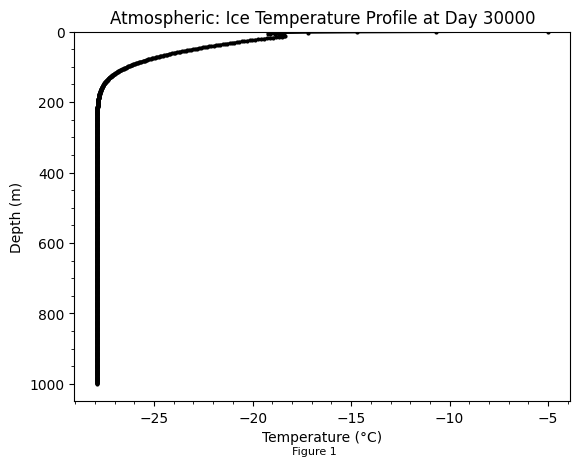

In [ ]:
# ATMOSPHERIC TEMPERATURE PROFILE PLOT
### plot how the temperature evolves through time and how this is different in each layer
plot_step = 30000 #choose which time step to plot
plot_depth = np.arange(0, depth, dz) #depth of each layer
plt.plot(T_output_atm[plot_step],plot_depth,'ok-', markersize=2) #plot layer temperature versus depth
plt.xlabel('Temperature (°C)') #label the x-axis
plt.ylabel('Depth (m)') #label the y-axis
plt.title(f'Atmospheric: Ice Temperature Profile at Day {plot_step}')
plt.ylim(bottom=-0.05) #limit the y-axis
plt.gca().invert_yaxis() #switch the direction of the y-axis
plt.minorticks_on()
plt.figtext(0.5, 0.0, "Figure 1", ha="center", fontsize=8)

#code justin -- taken from week 9 NB2 prac

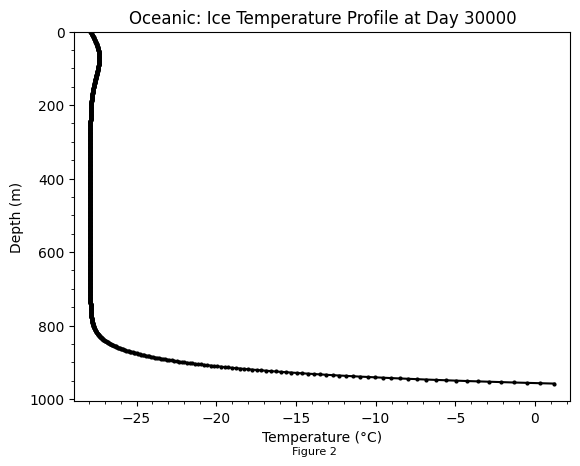

In [ ]:
# OCEANIC TEMPERATURE PROFILE PLOT
plot_step_ocean = min(30000, len(T_output_ocean) - 1)
plot_depth_ocean = np.arange(len(T_output_ocean[plot_step_ocean])) * dz

plt.figure()
plt.plot(T_output_ocean[plot_step_ocean], plot_depth_ocean, 'ok-', markersize=2)
plt.xlabel('Temperature (°C)')
plt.ylabel('Depth (m)')
plt.title(f'Oceanic: Ice Temperature Profile at Day {plot_step_ocean}')
plt.ylim(bottom=-0.05) #limit the y-axis
plt.xlim(min(T_output_ocean[plot_step_ocean]) - 1, max(T_output_ocean[plot_step_ocean]) + 1)
plt.gca().invert_yaxis() #switch the direction of the y-axis
plt.figtext(0.5, 0.0, "Figure 2", ha="center", fontsize=8)
plt.minorticks_on()

# Ellie's code

**Atmospheric surface temperature with seasonal cycle, showing the exponential warming of the atmosphere and ocean under RCP 8.5 climate scenario**

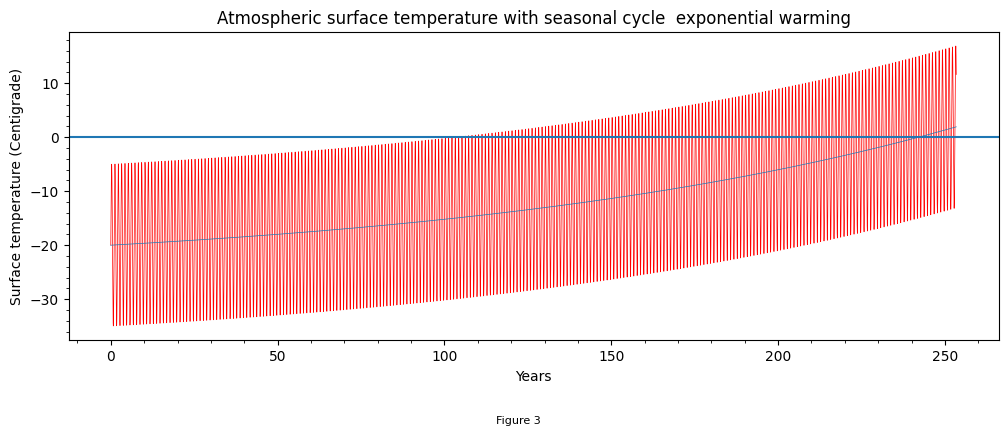

In [ ]:

### when orignally ploting this we were undabe to figure out how to achive the y axis ie time
## we used ai to sugest using the secounds and converting back into years to plot ear on the
## y axis- it also sugested adding the trend line for visual effects

time_years_atm = np.arange(len(T_atm_series)) * dt / (365.25 * 86400)
t_arr = np.arange(len(T_atm_series)) * dt

### trend that was used in the equation in the numerical model above
trend = T_mean + C_atm * (np.exp(r_exp_atm * t_arr) - 1)

plt.figure(figsize=(12,4))
plt.plot(time_years_atm, T_atm_series, color='red', markersize=0.5, linewidth=0.5)
plt.plot(time_years_atm, trend, linewidth=0.5)
plt.axhline(0) ## point of melt
plt.xlabel('Years')
plt.ylabel('Surface temperature (Centigrade)')
plt.title('Atmospheric surface temperature with seasonal cycle  exponential warming')
plt.figtext(0.5, -0.1, "Figure 3", ha="center", fontsize=8)
plt.minorticks_on()

# code justin Ai assited with this as I had issues

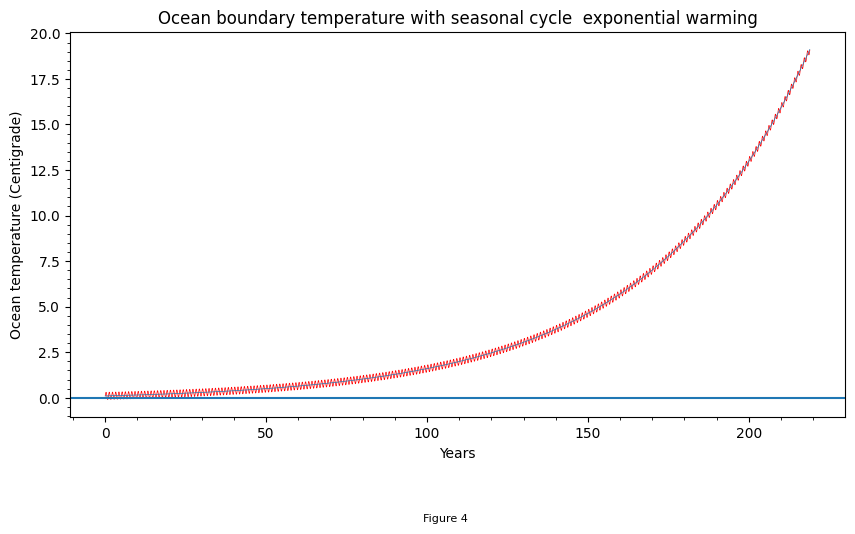

In [ ]:
### when orignally ploting this we were undabe to figure out how to achive the y axis ie time
## we used ai to sugest using the secounds and converting back into years to plot ear on the y axis
time_years_oc = np.arange(len(T_ocean_series)) * dt / (365.25 * 86400)
t_arr_oc = np.arange(len(T_ocean_series)) * dt

### trend that was used in the equation in the numerical model above
trend_oc = T_ocean_mean + C_ocean * (np.exp(r_exp_oc * t_arr_oc) - 1)

plt.figure(figsize=(10,5))
plt.plot(time_years_oc, T_ocean_series, color='red', markersize=0.5, linewidth=0.5)
plt.plot(time_years_oc, trend_oc, linewidth=0.5)
plt.axhline(0)
plt.xlabel('Years')
plt.ylabel('Ocean temperature (Centigrade)')
plt.title('Ocean boundary temperature with seasonal cycle  exponential warming')
plt.figtext(0.5, -0.1, "Figure 4", ha="center", fontsize=8)
plt.minorticks_on()

# Ellie's code

**Intresting note/limitation**


The exponetial rate of the ocean warming under a rcp 8.5 scenario seems very unrealistic. i don't think under htese conditons we would see an increase to antartic waters of over 15 degrees.

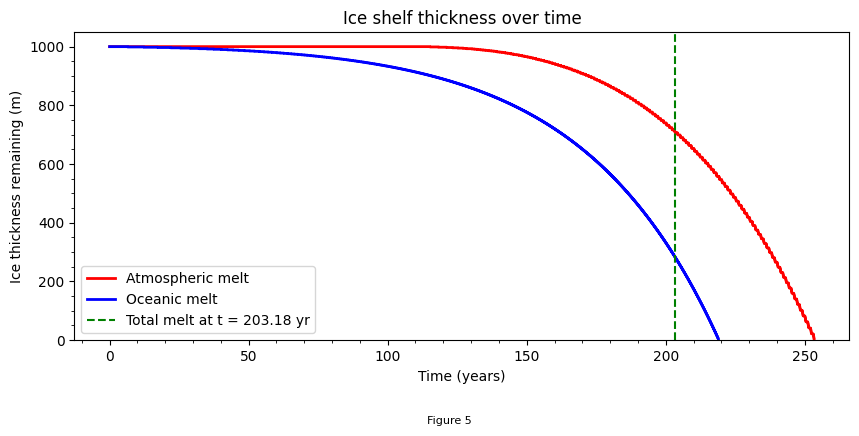

In [ ]:
# ATMOSPHERIC + OCEANIC PLOT - ICE THICKNESS OVER TIME

# In order to determine the point at which the ice sheet is completely melted we have to solve the
# equation loss_atm + loss_ocean = H0 (original thickness: 1000m), this can be rearranged to give
# thickness_atm + thickness_ocean = H0 (as loss_atm = H0-thickness_atm , etc.)
# used AI to help us determine how to solve this equation from the data and plot the line

from scipy.interpolate import interp1d # import required for interpolation
H0 = 1000 # the original thickness used in the model

# The simulations run for different lengths of time so we need to align them,
# from AI suggestions interpolating them both onto a common time axis is the cleanest method

# Build a common time axis spanning only the overlap between both simulations
t_min = max(time_years_atm[0], time_years_oc[0])
t_max = min(time_years_atm[-1], time_years_oc[-1])
t_common = np.linspace(t_min, t_max, num=10000)

# Interpolate both arrays onto the common axis
f_atm   = interp1d(time_years_atm,   ice_thickness_atm,   bounds_error=False, fill_value=0)
f_ocean = interp1d(time_years_oc, ice_thickness_ocean,  bounds_error=False, fill_value=0)

combined_remaining = f_atm(t_common) + f_ocean(t_common)

# Find melt point
melt_indices = np.where(combined_remaining <= H0)[0]

## plot to visualise how the ice melts over time
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_years_atm,   ice_thickness_atm,   color='red', linewidth=2, label='Atmospheric melt')
ax.plot(time_years_oc, ice_thickness_ocean, color='blue', linewidth=2, label='Oceanic melt')

# Add the line of complete melt to the plot
if len(melt_indices) > 0:
    melt_time = t_common[melt_indices[0]]
    ax.axvline(x=melt_time, color='green', linestyle='--', linewidth=1.5,
               label=f'Total melt at t = {melt_time:.2f} yr')
else:
    print("Ice sheet does not fully melt within simulation period.")

ax.set_xlabel('Time (years)')
ax.set_ylabel('Ice thickness remaining (m)')
ax.set_title('Ice shelf thickness over time')
ax.set_ylim(bottom=0)
ax.legend()
ax.minorticks_on()
plt.figtext(0.5, -0.1, "Figure 5", ha="center", fontsize=8)
plt.show()

### Ellie and Clover's code

#Interpretation: Owen/Ed

### Model Interpretation
Our model simulates the West Antarctic Ice Sheet melt using a layered ice column (1000 layers of which were all 1mm thick), and its interaction with heat transfer driven by a finite difference diffusion equation. This approach (structurally identical to classical soil heat diffusion models) helped a lot in our hypothesis’ regard, because ice melt is driven by heat moving through a layered medium from a warm boundary into a cold interior. With this, two models were constructed: one driven by atmospheric temperatures at the surface (top-down), and one driven by ocean temperature at the base (bottom-up), which allowed us to directly compare the 2 mechanisms side-by-side.

Both boundary temperatures follow an exponential warming trend calibrated to the SSP5-8.5 scenario - 4.8 degrees celsius atmospheric warming, and 1.5 degrees celsius ocean warming by 2100 - with a seasonal cycle overlaid. This helped capture both the long-term climate signal and the year to year summer and winter variation that controls when melt really occurs. To compute the melt itself, we used a fusion rate equation that removes ice layers only when the boundary temperature exceeds 0 degrees celsius, which ensured that the model was physically constrained to realistic melt conditions. We then combined the 2 models by interpolating each ice thickness curve onto a common time axis, allowing us to estimate the total melt timeline point as the moment where their combined ice loss reached 1000m.

### Physical Interpretation
In figure 1, we can see that after around 82 years, atmospheric warming has only penetrated the top 150m of a 1000m ice column, with deeper ice remaining around its initial temperature of -27.9 degrees celsius. This slow penetration reflects ice’s low thermal diffusivity, and the fact that the atmospheric mean temperature spends much of the simulation <0 degrees. Figure 2, by contrast, shows ocean driven warming has penetrated around 200m from the base in the same timeframe, with bottom temperatures already exceeding 0 degrees. This meaning, that melting has begun from below while the atmosphere has not yet initiated any significant melt. Thus, directly supporting our hypothesis that oceanic heat transfer is more efficient and more impactful in the short term.

Figures 3 and 4 show why this difference exists. Atmospheric temperature in figure 3, oscillates by around 15 from the rising mean, beginning at -20 degrees and only crossing 0 degrees during summer peaks from around year 100 and onwards - so atmospheric melt is delayed. The oceans boundaries in figure 4 start at +0.1 degrees and rise continuously, meaning that ocean driven melt is active every day from the start of the simulation. A much smaller seasonal oscillation in the ocean (+0.2 versus +-15 degrees) reflects a high thermal heat capacity of water, which buffers temperature variations and maintains an almost constant melt year round.
Figure 5 compiles these findings and is the central result of our work. The ocean melt curve (in the blue) declines immediately and accelerates strongly after year 150, while the atmospheric curve (in the red) remains nearly flat until year 150, before steepening. These two curves converge at t = 203 years, representing a complete melt of the ice sheet under SSP5-8.5. This confirms our hypothesis in both regards: oceanic melt is faster throughout the duration of the simulation, and the high emissions SSP5-8.5 scenario produces a complete ice sheet melt on a timescale of around 200 years - dramatically shorter than the hundreds to thousands of years projected under more moderate climate emissions scenarios. This shows how strongly the choice of climate pathway decides the fate of the ice sheet.

###Limitations
The two models run independently rather than a combined system, meaning that real world feedbacks between atmospheric and oceanic warming (like meltwater getting fresher and slowing circulation) are not fully captured. The ocean warming becomes unrealistic beyond the 2100 window, reaching around 19 degrees by year 220, which is far above any realistic Antarctic ocean projection and likely causes the ocean melt rate to be overestimated in the larger stages of our simulation.

The ocean fusion rate we coded is also lower than the atmospheric fusion rate, meaning that the ocean’s dominance in figure 5 is driven by its continuous above zero temperature rather than the intended 3x efficiency advantage (fixing this would make our findings more robust).

We have also simplified the omission of snowfall accumulation, ice flow dynamics, albedo feedbacks, and spatial variation across the ice sheet. Running the simulation under a lower emissions scenario such as SSP1-2.6 and comparing our 2 results would be a good way to redo this, by directly addressing the second research question in quantifying how sensitively the melt timeline responds to the choice of climate pathway.


---




#Reflections
---









## Freddie

This week my role was Github and integration. I wanted this role as I knew I would be busier later in the week and wanted to get my work done early. As Github manager, my role was to commit the code, organise the repository etc. The major difficulty I had in my role was that my laptop had some issues that cased Gitgub to be very slow. It would take around 20 minutes for github to load and then even longer to run any code. Aside from this, my role was relatively smooth. My amazing team mates made this role wasy as, at the point in the course, we all know what each role entails and are relatively confident with coding. My finaljob was to do a final committ and then upload the link into canvas.




---
## Clover

This week my role a data steward was significantly different to past weeks. The modelling content doesn't require imported data for analysis, instead I focused on wrapping my head around our ice sheet melt model concept. To do this I did some broad research into the types of parameters involved, had a look at how the soil model could be adapted to suit our purposes and used AI to understand how our model equations could be constructed. Essentially I established the baseframe from which Justin and Ellie did a fantastic job of implimenting and updating with specific parameters. Later in the week I jumped back on to help clean up some of the analysis code, this involved: helping determine the best way to find the time at which the ice sheet fully melted, adding some documentation to our explaination of the climate model we used and setting up each figure for Owen and Ed to interpret. This week's work could be further improved by running another model with a lower SSP climate model to compare the impacts of climate change scenarios on ice sheet loss - this is something we may try to impliment if we select this as one of our final projects.

---
## Eloise

This week, me and Justin collaborated on both the Data Analysis and Data Visualisation roles as they were very intertwined. Once we began our roles, we realised we had taken on a much more complex topic than originally anticipated so it took a lot of time and code adjustments to get the right graphs that we wanted, and we used a bit of AI in places we were confused, such as the final part of setting up our Atmospheric and Oceanic models using code. I focused mainly on the ocean code and visualisation, as well as plotting both the oceanic and atmospheric curves to reveal change in ice shelf thickness over time. Clover further helped figure out how to plot the time at which the ice sheet fully melted. I found my role this week challenging, and required a lot of communication with Justin and Clover. When I first began my role, I need a fair bit of time to conceptualise what was happening, however Clover had clearly noted the parameters, equations and how to use them which was very helpful. I also changed some of the original parameters we had, as the ice shelf originally melted in under 3 years, which was unrealistic. We implemented knowledge from the Week 9 practical and lectorial, then further added code required to graph both of the models. Overall, I think clear communication was vital in bringing this project together, and we did a great job in coding and visualising a complex scenario.

---

## Ed

This week my role did not impact the project. Owen constructed the interpretations for both model and physical results. I cannot contribute an experience I had regarding meaningful involvement within this project. The only potential insight I have to offer (if considering the role of quality control/reproducibility) is that having visited this project without prior knowledge, I have found that the use of text to both define functions/calculations and to break up work into a step by step method has made the transition from model to physical intepretation seamless. The model is much easier to comprehend thanks to a clear presentation of the parameters involved. I mainly use this reflection to support the work my group did for this project.

---

## Owen
My role as Interpretaion and Narrative lead this week was a little different to last week, as it required a lot more attention to detail in the code of our group project. As the rest of the group worked collaboratively, it was my job to consolidate their findings and put into words what the resulting graphs actually meant. This required both an understanding of the models we applied and the values we used - of which were closely related to the lectures and practicals we covered in class, with a little improvisation on our part. I felt as if the figures produced were easy to interpret, as our objective was to make our model as uncomplicated as possible, with as little convolution as possible. This being said, the graphs gave clear trends, and as such, my job to analyse the physical results was straightforward (simply comparing the two models and realting them to a wider context in the climate models and data we used). Intepreting the models was slightly more difficult, as it was based around my existing understanding of the lecture material,and further applying this undertsanding to the code my groupmates collaboratively worked on. Although it took some time, relating the results to our models made sense and only required a quick read through of the steps we took to reach certain outcomes.

---


## Justin

This week, my task required extensive teamwork between Clover, Eloise, and me, since data stewardship, analysis and visualisation roles went hand in hand. At the beginning, we were ambitious but unaware of the obstacles ahead. After the Week 9 practical, we planned to plot a simplified ice shelf model, introducing variables such as fusion rates and exponential climate change. The main challenge I faced was understanding both the numerical modelling concepts and the programming steps needed to implement them. While it was easy to gel out a question on paper, constructing the model was another thing.


To address this, the team and I used artificial intelligence as an aid. We worked alongside AI, taking our current attempts and cluelessness, and were able to create a final product that represents an ice shelf melting, albeit not correct by any stretch of the imagination.  We were aware of possible issues like hallucination and or fabricated artifacts ect, so our approach involved validating AI outputs and ensuring we truly understood what the AI was suggesting/creating. Visual plots aided our consultation and result validation. While using AI was not ideal for this scenario, the approach gave us greater insight into numerical models' potential than a simpler project would have, even if it took more time.


Finally, it was vital to communicate our progress to the rest of the team. It is very easy to get complacent and assume others can "read our minds" or automatically know the specific steps we took to achieve our results. Clear communication ensured everyone understood the logic behind our work.